# LMAPR1492 : Tâche 9 -> Ph_dos

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from pymatgen.ext.matproj import MPRester
import plotly.graph_objects as go
import math

In [26]:
# Récupération de la structure 
with MPRester("rEVEIFsc61iExKZbJ2QyepniwSgJ1m6W") as m:
    prim_struc = m.get_structure_by_material_id("mp-570213")
    ph_dos = m.get_phonon_dos_by_material_id("mp-570213")
    
temperatures = np.arange(0.001,1000,5)
R = 8.314  # constante des gaz parfaits
nat = len(prim_struc)  # nombre d'atomes
ph_cv = np.array([ph_dos.cv(temperatures[i]) for i in range(len(temperatures))])/(3*nat*R) 

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving PhononBSDOSDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

## La chaleur spécifique en fonction de la température pour mon matériaux 

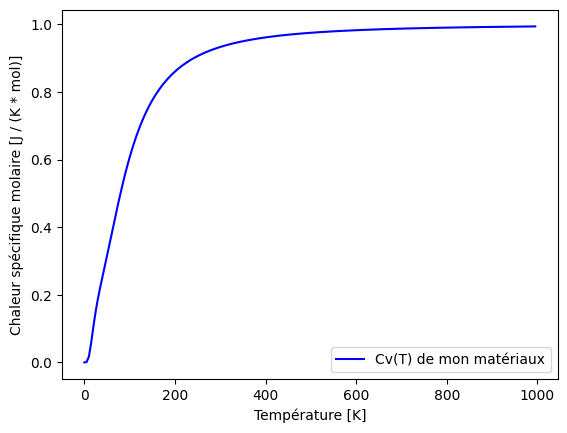

In [27]:
plt.plot(temperatures, ph_cv, color="blue", label="Cv(T) de mon matériaux")
cv_list = []
plt.xlabel("Température [K]")
plt.ylabel("Chaleur spécifique molaire [J / (K * mol)]")
plt.legend()
plt.show()

## Les températures de Debye et d'Einstein 

Le modèle de Debye par du principe que les fréquences ont une dispersion linéaire: 

ω=v⋅q, où v est la vitesse de phase et q est le vecteur d'onde.

Le modèle d'Einstein, quant à lui, fait l'hypothèse que les fréquences sont égales à une fréquence naturelle de vibration. 
En effet, on néglige l'interaction entre atomes.

 
 
 


In [ ]:
# Modèle d'Einstein

def fE(ThetaE, T):
    toReturn = (ThetaE/T)**2 * np.exp(ThetaE/T) / (np.exp(ThetaE/T) - 1)**2
    if math.isnan(toReturn):
        toReturn = 0
    return toReturn

# Modèle de Debye

def fD(ThetaD, T):
    # Il va falloir intégrer de 0 à ThetaD/T. On va utiliser la méthode des trapèzes fournie par numpy
    # création d'un linspace pour l'intégrale
    x = np.linspace(0.00001, ThetaD/T, 50)  # Peut pas commencer à 0 sinon division par 0
    y = (x**4 * np.exp(x)) / (np.exp(x) - 1)**2
    integral =  np.trapz(y, x)
    toReturn = 3 * (T / ThetaD)**3 * integral
    if math.isnan(toReturn):  # Peut arriver si T = 0
        toReturn = 0
    return toReturn
    

# Fonction SquaredError -
def getSquaredError(Parameter, T, Cv, f):
    squaredError = 0
    for i in range(len(T)):
        # print(f"Cv[i] = {Cv[i]}, f(Parameter, T[i]) = {f(Parameter, T[i])}")
        squaredError += (Cv[i] - f(Parameter, T[i]))**2
    return squaredError


def find_minima(start, end, step, T, Cv, f):
    numbers = np.arange(start, end, step=step)
    result = []
    for i in range(len(numbers)):
        result.append(getSquaredError(numbers[i], T, Cv, f))
    return numbers[np.argmin(result)]


tE = find_minima(270, 285, 0.001, temperatures, ph_cv, fE)  
tD = find_minima(372, 379, 0.001, temperatures, ph_cv, fD)  


/tmp/ipykernel_2678109/3551565943.py:4: RuntimeWarning: overflow encountered in exp
  toReturn = (ThetaE/T)**2 * np.exp(ThetaE/T) / (np.exp(ThetaE/T) - 1)**2
/tmp/ipykernel_2678109/3551565943.py:4: RuntimeWarning: invalid value encountered in scalar divide
  toReturn = (ThetaE/T)**2 * np.exp(ThetaE/T) / (np.exp(ThetaE/T) - 1)**2
/tmp/ipykernel_2678109/3551565943.py:15: RuntimeWarning: overflow encountered in exp
  y = (x**4 * np.exp(x)) / (np.exp(x) - 1)**2
/tmp/ipykernel_2678109/3551565943.py:15: RuntimeWarning: invalid value encountered in divide
  y = (x**4 * np.exp(x)) / (np.exp(x) - 1)**2


## Comparaison 

In [ ]:
cv_E = []
cv_D = []
for i in T:
    cv_E.append(modele_einstein(tmp_E, i));cv_D.append(modele_debye(tmp_D, i))

plt.plot(T, cv_list, color="blue", label="Cv(T)")
plt.plot(T, cv_E, label="Cv(T) Einstein")
plt.plot(T, cv_D, label="Cv(T) Debye")
plt.grid(color='yelow', linestyle='--', linewidth=0.5)
plt.xlabel("Température [K]")
plt.ylabel("Chaleur spécifique molaire [J / (K * mol)]")
plt.legend()
plt.show()

## Représentation des trois densités d'états

In [ ]:
# fréquence de Einstein 
freq_E = tmp_E * kb / h / 10**12   # (en THz)

#  fréquence de Debye 
freq_D = tmp_D * kb / h / 10**12  # en THz

# Calcul de la densité d'états de Debye
g_D = np.zeros_like(freq)
for i in range(len(freq)):
    if freq[i] < freq_D:
        g_D[i] = 9 * nat * freq[i]**2 / ( freq_D**3)

plt.plot(freq, densities, color="blue", label="DOS")
plt.axvline(x=freq_E, color='r', linestyle='--', label="Fréquence d'Einstein")
plt.plot(freq, g_D, color="green", label="DOS Debye")
plt.legend()
plt.xlabel("Fréquence [THz]")
plt.ylabel("Densité d'états")
plt.show()